In [1]:
import torch
print(torch.__version__)
print(torch.version.cuda)

2.10.0+cpu
None


In [2]:
import torch
TORCH = torch.__version__.split('+')[0]
CUDA = 'cu' + torch.version.cuda.replace('.', '') if torch.cuda.is_available() else 'cpu'

!pip install torch_geometric
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.8 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 31.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 50.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.2/828.2 kB 43.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.9/306.9 kB 17.0 MB/s eta 0:00:00


In [3]:
import torch_geometric
from torch_geometric.nn import GATConv
print("PyTorch Geometric version:", torch_geometric.__version__)

# Trivial sanity-check graph: 3 nodes, 2 edges
import torch
x = torch.rand((3, 16))  # 3 nodes, 16 features each
edge_index = torch.tensor([[0, 1], [1, 2]], dtype=torch.long).t().contiguous()
conv = GATConv(16, 8)
out = conv(x, edge_index)
print("GAT output shape:", out.shape)  # should be [3, 8]

PyTorch Geometric version: 2.8.0.post1
GAT output shape: torch.Size([3, 8])


In [4]:
!pip install gdown
!gdown --folder "https://drive.google.com/drive/folders/18yJcHXhzOv7H89t-Lda6phheAicLqMuZ" -O /kaggle/working/acne04

Retrieving folder contents
Processing file 1ysutxP3IHKhQA8brdwPlhwbduo-kYt1x Classification.tar
Processing file 1NqsL5mlI3iTsPmjvVX7y6GUileM7oL5v Detection.tar
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1ysutxP3IHKhQA8brdwPlhwbduo-kYt1x
From (redirected): https://drive.google.com/uc?id=1ysutxP3IHKhQA8brdwPlhwbduo-kYt1x&confirm=t&uuid=b1bdb557-77aa-4312-9060-b75ee5236fbb
To: /kaggle/working/acne04/Classification.tar
100%|███████████████████████████████████████| 1.13G/1.13G [00:07<00:00, 159MB/s]
Downloading...
From: https://drive.google.com/uc?id=1NqsL5mlI3iTsPmjvVX7y6GUileM7oL5v
To: /kaggle/working/acne04/Detection.tar
100%|███████████████████████████████████████| 6.07M/6.07M [00:00<00:00, 182MB/s]
Download completed


In [5]:
import tarfile

with tarfile.open('/kaggle/working/acne04/Classification.tar') as t:
    t.extractall('/kaggle/working/acne04/classification', filter='data')

with tarfile.open('/kaggle/working/acne04/Detection.tar') as t:
    t.extractall('/kaggle/working/acne04/detection', filter='data')

In [6]:
import os

print("=== Classification folder (deeper) ===")
for root, dirs, files in os.walk('/kaggle/working/acne04/classification'):
    depth = root.count(os.sep) - '/kaggle/working/acne04/classification'.count(os.sep)
    print(root, "->", dirs[:5], "|", len(files), "files")
    if depth >= 3:
        break

print("\n=== Detection folder (deeper) ===")
for root, dirs, files in os.walk('/kaggle/working/acne04/detection'):
    depth = root.count(os.sep) - '/kaggle/working/acne04/detection'.count(os.sep)
    print(root, "->", dirs[:5], "|", len(files), "files")
    if depth >= 3:
        break

=== Classification folder (deeper) ===
/kaggle/working/acne04/classification -> ['Classification'] | 0 files
/kaggle/working/acne04/classification/Classification -> ['JPEGImages'] | 10 files
/kaggle/working/acne04/classification/Classification/JPEGImages -> [] | 1457 files

=== Detection folder (deeper) ===
/kaggle/working/acne04/detection -> ['Detection'] | 0 files
/kaggle/working/acne04/detection/Detection -> ['VOC2007'] | 0 files
/kaggle/working/acne04/detection/Detection/VOC2007 -> ['Annotations', 'ImageSets'] | 0 files
/kaggle/working/acne04/detection/Detection/VOC2007/Annotations -> [] | 1457 files


In [7]:
import os
from collections import Counter

def summarize_folder(base_path, max_examples=5):
    print(f"\n{'='*60}")
    print(f"Summarizing: {base_path}")
    print('='*60)
    
    ext_counter = Counter()
    dir_count = 0
    file_count = 0
    examples = []
    
    for root, dirs, files in os.walk(base_path):
        dir_count += len(dirs)
        for f in files:
            file_count += 1
            ext = os.path.splitext(f)[1].lower()
            ext_counter[ext] += 1
            if len(examples) < max_examples:
                examples.append(os.path.join(root, f))
    
    print(f"Total directories: {dir_count}")
    print(f"Total files: {file_count}")
    print(f"\nFile types found:")
    for ext, count in ext_counter.most_common():
        print(f"  {ext if ext else '(no extension)'}: {count}")
    
    print(f"\nSample file paths:")
    for ex in examples:
        print(f"  {ex}")

summarize_folder('/kaggle/working/acne04/classification')
summarize_folder('/kaggle/working/acne04/detection')


Summarizing: /kaggle/working/acne04/classification
Total directories: 2
Total files: 1467

File types found:
  .jpg: 1457
  .txt: 10

Sample file paths:
  /kaggle/working/acne04/classification/Classification/NNEW_test_0.txt
  /kaggle/working/acne04/classification/Classification/NNEW_trainval_0.txt
  /kaggle/working/acne04/classification/Classification/NNEW_test_2.txt
  /kaggle/working/acne04/classification/Classification/NNEW_test_1.txt
  /kaggle/working/acne04/classification/Classification/NNEW_test_4.txt

Summarizing: /kaggle/working/acne04/detection
Total directories: 5
Total files: 1467

File types found:
  .xml: 1457
  .txt: 10

Sample file paths:
  /kaggle/working/acne04/detection/Detection/VOC2007/Annotations/levle1_4.xml
  /kaggle/working/acne04/detection/Detection/VOC2007/Annotations/levle1_289.xml
  /kaggle/working/acne04/detection/Detection/VOC2007/Annotations/levle1_598.xml
  /kaggle/working/acne04/detection/Detection/VOC2007/Annotations/levle1_456.xml
  /kaggle/working/ac

In [8]:
import xml.etree.ElementTree as ET

# 1. Look at one raw annotation file
xml_path = '/kaggle/working/acne04/detection/Detection/VOC2007/Annotations/levle1_622.xml'
with open(xml_path, 'r') as f:
    print(f.read())

<annotation>
	<folder>VOC2007</folder>
	<filename>levle1_622.jpg</filename>
	<source>
		<database>My Database</database>
		<annotation>VOC2007</annotation>
		<image>flickr</image>
		<flickrid>NULL</flickrid>
	</source>
	<owner>
		<flickrid>NULL</flickrid>
		<name>xiaoxianyu</name>
	</owner>
	<size>
		<width>3112</width>
		<height>3456</height>
		<depth>3</depth>
	</size>
	<segmented>0</segmented>
	<object>
		<name>fore</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>1834</xmin>
			<ymin>2190</ymin>
			<xmax>2003</xmax>
			<ymax>2366</ymax>
		</bndbox>
	</object>
	<object>
		<name>fore</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>1160</xmin>
			<ymin>1876</ymin>
			<xmax>1367</xmax>
			<ymax>2083</ymax>
		</bndbox>
	</object>
	<object>
		<name>fore</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>1696</xmin>

In [9]:
# 2. Look at one split file to understand train/test structure
with open('/kaggle/working/acne04/classification/Classification/NNEW_trainval_0.txt', 'r') as f:
    lines = f.readlines()
print(f"Total entries: {len(lines)}")
print("First 5 lines:")
for line in lines[:5]:
    print(" ", line.strip())

Total entries: 1165
First 5 lines:
  levle0_0.jpg  0  3
  levle0_1.jpg  0  3
  levle0_100.jpg  0  2
  levle0_101.jpg  0  1
  levle0_102.jpg  0  3


In [10]:
# 3. Parse the XML properly and pull out the bounding boxes
tree = ET.parse(xml_path)
root = tree.getroot()

print("Filename referenced:", root.find('filename').text if root.find('filename') is not None else "N/A")
size = root.find('size')
print("Image size:", size.find('width').text, "x", size.find('height').text if size is not None else "N/A")

print("\nBounding boxes found:")
for obj in root.findall('object'):
    name = obj.find('name').text
    bbox = obj.find('bndbox')
    xmin, ymin = bbox.find('xmin').text, bbox.find('ymin').text
    xmax, ymax = bbox.find('xmax').text, bbox.find('ymax').text
    print(f"  class={name}, box=({xmin},{ymin})-({xmax},{ymax})")

Filename referenced: levle1_622.jpg
Image size: 3112 x 3456

Bounding boxes found:
  class=fore, box=(1834,2190)-(2003,2366)
  class=fore, box=(1160,1876)-(1367,2083)
  class=fore, box=(1696,3079)-(1842,3255)
  class=fore, box=(1160,3278)-(1313,3439)
  class=fore, box=(991,3202)-(1145,3324)
  class=fore, box=(1060,3125)-(1290,3255)
  class=fore, box=(1014,2934)-(1145,3018)
  class=fore, box=(807,2911)-(991,3041)
  class=fore, box=(1206,964)-(1352,1102)
  class=fore, box=(1053,1309)-(1252,1501)


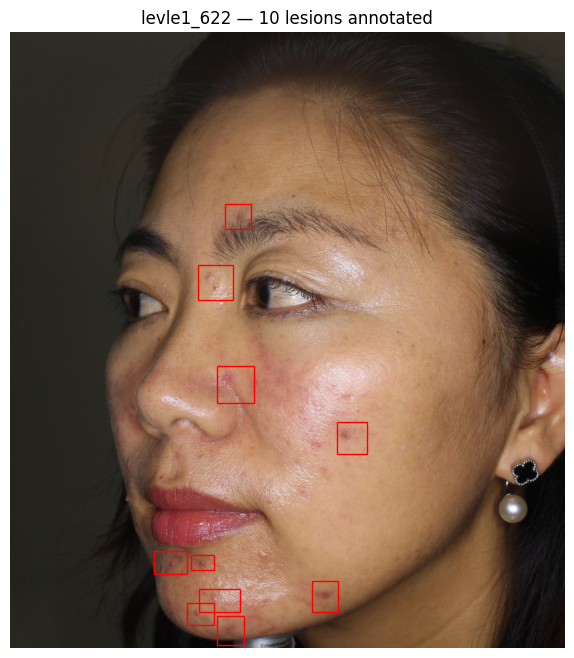

In [11]:
# 4. Visual check — draw the boxes on the actual image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

img_path = '/kaggle/working/acne04/classification/Classification/JPEGImages/levle1_622.jpg'
img = Image.open(img_path)

fig, ax = plt.subplots(1, figsize=(8, 8))
ax.imshow(img)

for obj in root.findall('object'):
    bbox = obj.find('bndbox')
    xmin, ymin = int(bbox.find('xmin').text), int(bbox.find('ymin').text)
    xmax, ymax = int(bbox.find('xmax').text), int(bbox.find('ymax').text)
    rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                               linewidth=1, edgecolor='red', facecolor='none')
    ax.add_patch(rect)

plt.title(f"levle1_622 — {len(root.findall('object'))} lesions annotated")
plt.axis('off')
plt.show()

In [12]:
import xml.etree.ElementTree as ET
import os

def count_lesions_in_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    return len(root.findall('object'))

# Check a handful of entries from the split file against their actual XML lesion counts
detection_ann_dir = '/kaggle/working/acne04/detection/Detection/VOC2007/Annotations'

with open('/kaggle/working/acne04/classification/Classification/NNEW_trainval_0.txt', 'r') as f:
    lines = f.readlines()

print(f"{'Filename':<20} {'Split_col2':<12} {'Split_col3':<12} {'XML_lesion_count':<18} {'Match?'}")
for line in lines[:10]:
    parts = line.strip().split()
    filename = parts[0]
    col2 = parts[1]
    col3 = parts[2]
    
    xml_name = filename.replace('.jpg', '.xml')
    xml_path = os.path.join(detection_ann_dir, xml_name)
    
    if os.path.exists(xml_path):
        actual_count = count_lesions_in_xml(xml_path)
        match = "✓" if str(actual_count) == col3 else ("✓ (col2)" if str(actual_count) == col2 else "✗")
    else:
        actual_count = "XML not found"
        match = "?"
    
    print(f"{filename:<20} {col2:<12} {col3:<12} {str(actual_count):<18} {match}")

Filename             Split_col2   Split_col3   XML_lesion_count   Match?
levle0_0.jpg         0            3            3                  ✓
levle0_1.jpg         0            3            3                  ✓
levle0_100.jpg       0            2            2                  ✓
levle0_101.jpg       0            1            1                  ✓
levle0_102.jpg       0            3            3                  ✓
levle0_104.jpg       0            1            1                  ✓
levle0_105.jpg       0            1            1                  ✓
levle0_106.jpg       0            1            1                  ✓
levle0_108.jpg       0            1            1                  ✓
levle0_109.jpg       0            1            1                  ✓


In [13]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import xml.etree.ElementTree as ET
import os


class ACNE04Dataset(Dataset):
    """
    Loads ACNE04 images together with their bounding-box annotations
    (from Detection/VOC2007/Annotations) and severity label
    (from the Classification split files).
    """

    def __init__(self, root, split_file, transform=None):
        """
        root: path to the acne04 folder (containing classification/ and detection/ subfolders)
        split_file: e.g. 'NNEW_trainval_0.txt' or 'NNEW_test_0.txt'
        transform: optional torchvision transform applied to the image
        """
        self.image_dir = os.path.join(root, 'classification/Classification/JPEGImages')
        self.ann_dir = os.path.join(root, 'detection/Detection/VOC2007/Annotations')
        self.transform = transform

        split_path = os.path.join(root, 'classification/Classification', split_file)
        self.entries = []
        with open(split_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 3:
                    filename, severity, lesion_count = parts[0], int(parts[1]), int(parts[2])
                    self.entries.append((filename, severity, lesion_count))

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        filename, severity, lesion_count = self.entries[idx]

        # Load image
        img_path = os.path.join(self.image_dir, filename)
        image = Image.open(img_path).convert('RGB')

        # Load bounding boxes from matching XML
        xml_path = os.path.join(self.ann_dir, filename.replace('.jpg', '.xml'))
        boxes = []
        if os.path.exists(xml_path):
            tree = ET.parse(xml_path)
            root_el = tree.getroot()
            for obj in root_el.findall('object'):
                bbox = obj.find('bndbox')
                xmin = int(bbox.find('xmin').text)
                ymin = int(bbox.find('ymin').text)
                xmax = int(bbox.find('xmax').text)
                ymax = int(bbox.find('ymax').text)
                boxes.append([xmin, ymin, xmax, ymax])

        boxes = torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4))

        if self.transform:
            image = self.transform(image)

        sample = {
            'image': image,
            'boxes': boxes,
            'severity': severity,
            'lesion_count': lesion_count,
            'filename': filename
        }
        return sample


# Quick test
ds = ACNE04Dataset(root='/kaggle/working/acne04', split_file='NNEW_trainval_0.txt')
print(f"Dataset size: {len(ds)}")

sample = ds[0]
print(f"Filename: {sample['filename']}")
print(f"Severity: {sample['severity']}, Lesion count: {sample['lesion_count']}")
print(f"Image size: {sample['image'].size}")
print(f"Boxes shape: {sample['boxes'].shape}")

Dataset size: 1165
Filename: levle0_0.jpg
Severity: 0, Lesion count: 3
Image size: (525, 700)
Boxes shape: torch.Size([3, 4])


In [14]:
import os
os.makedirs('detection', exist_ok=True)

In [15]:
%%writefile detection/dataset.py
import torch
from torch.utils.data import Dataset
from PIL import Image
import xml.etree.ElementTree as ET
import os


class ACNE04Dataset(Dataset):
    """
    Loads ACNE04 images together with their bounding-box annotations
    (from Detection/VOC2007/Annotations) and severity label + lesion count
    (from the Classification split files: filename, severity[0-3], lesion_count).

    Verified against source: severity/lesion_count columns confirmed to match
    filename prefix (levleN_) and XML object count respectively (see
    notebooks/01_acne04_exploration.ipynb).
    """

    def __init__(self, root, split_file, transform=None):
        self.image_dir = os.path.join(root, 'classification/Classification/JPEGImages')
        self.ann_dir = os.path.join(root, 'detection/Detection/VOC2007/Annotations')
        self.transform = transform

        split_path = os.path.join(root, 'classification/Classification', split_file)
        self.entries = []
        with open(split_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 3:
                    filename, severity, lesion_count = parts[0], int(parts[1]), int(parts[2])
                    self.entries.append((filename, severity, lesion_count))

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        filename, severity, lesion_count = self.entries[idx]

        img_path = os.path.join(self.image_dir, filename)
        image = Image.open(img_path).convert('RGB')

        xml_path = os.path.join(self.ann_dir, filename.replace('.jpg', '.xml'))
        boxes = []
        if os.path.exists(xml_path):
            tree = ET.parse(xml_path)
            root_el = tree.getroot()
            for obj in root_el.findall('object'):
                bbox = obj.find('bndbox')
                xmin = int(bbox.find('xmin').text)
                ymin = int(bbox.find('ymin').text)
                xmax = int(bbox.find('xmax').text)
                ymax = int(bbox.find('ymax').text)
                boxes.append([xmin, ymin, xmax, ymax])

        boxes = torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4))

        if self.transform:
            image = self.transform(image)

        return {
            'image': image,
            'boxes': boxes,
            'severity': severity,
            'lesion_count': lesion_count,
            'filename': filename
        }

Writing detection/dataset.py
